In [2]:
from google.colab import files
uploaded = files.upload()


Saving Online Retail.xlsx to Online Retail (1).xlsx


In [3]:
import pandas as pd
df = pd.read_excel('Online Retail.xlsx')
print("Shape:", df.shape)
df.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()
df.isnull().sum()
df = df.dropna(subset=['CustomerID'])
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df = df[df['Country'] == 'United Kingdom']
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [6]:
import pandas as pd
import datetime as dt

In [7]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# New Section

In [8]:
reference_date = df['InvoiceDate'].max()
reference_date


Timestamp('2011-12-09 12:49:00')

In [9]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Re
    'InvoiceNo': 'nunique',                                    # Freq
    'TotalAmount': 'sum'                                       # Mon
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12747.0,1,11,4196.01
2,12748.0,0,210,33053.19
3,12749.0,3,5,4090.88
4,12820.0,2,4,942.34


In [10]:
# Remove -ve mon vals
rfm = rfm[rfm['Monetary'] > 0]


In [11]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])


In [12]:
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346.0,325,1,77183.60,1,1,5,115,7
1,12747.0,1,11,4196.01,5,5,5,555,15
2,12748.0,0,210,33053.19,5,5,5,555,15
3,12749.0,3,5,4090.88,5,4,5,545,14
4,12820.0,2,4,942.34,5,4,4,544,13


In [13]:
def segment_customer(score):
    if score >= 9:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'CustomerID': 'CustomerCount'})


,CustomerCount,Recency,Frequency,Monetary
Segment,,,,
At Risk,641,205.199688,1.060842,244.445881
Lost,170,283.258824,1.000000,140.154176
Loyal,2069,34.861769,6.817786,3165.173437
Potential,1040,101.654808,1.626923,534.389214


/tmp/ipython-input-14-2195578813.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=['Loyal', 'Potential', 'At Risk', 'Lost'], palette='Set2')


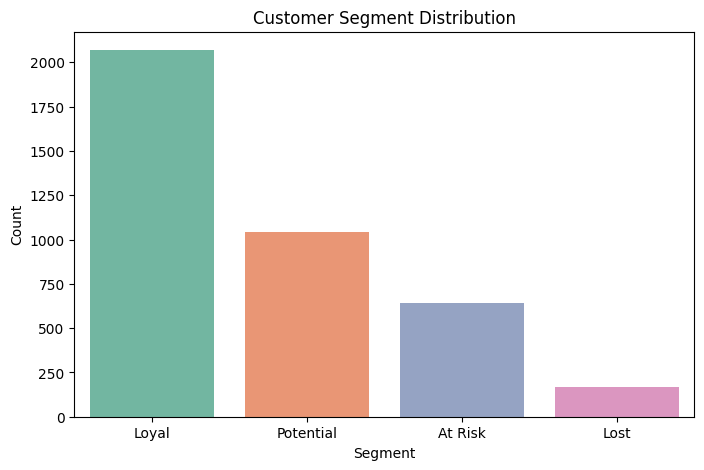

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Segment', order=['Loyal', 'Potential', 'At Risk', 'Lost'], palette='Set2')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()


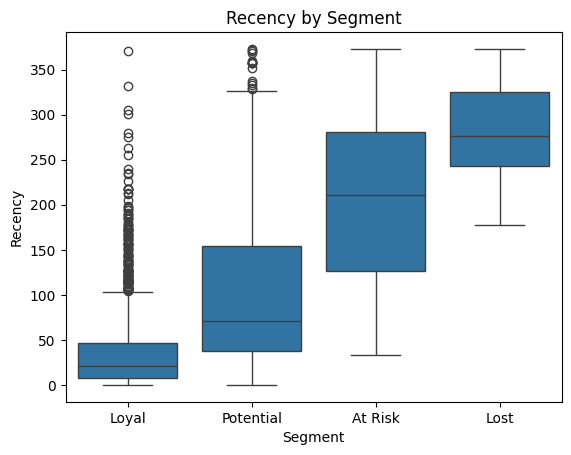

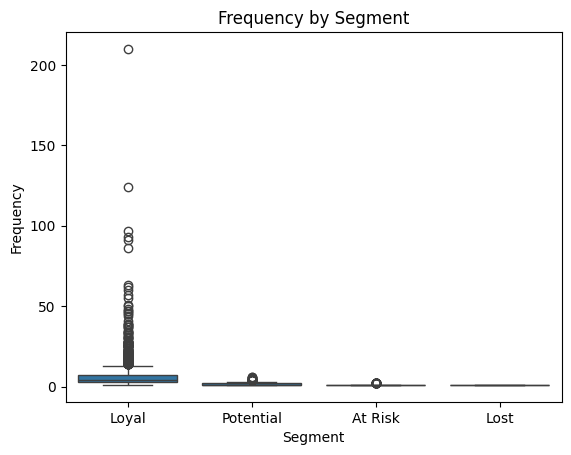

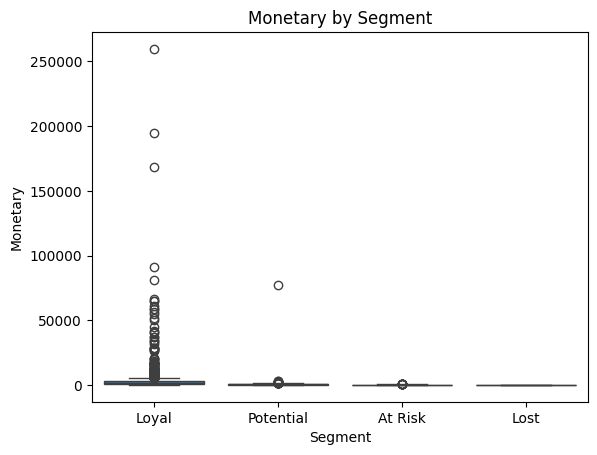

In [15]:
# R Bplot
sns.boxplot(data=rfm, x='Segment', y='Recency', order=['Loyal', 'Potential', 'At Risk', 'Lost'])
plt.title('Recency by Segment')
plt.show()

# Freq Bplot
sns.boxplot(data=rfm, x='Segment', y='Frequency', order=['Loyal', 'Potential', 'At Risk', 'Lost'])
plt.title('Frequency by Segment')
plt.show()

# Mon Bplot
sns.boxplot(data=rfm, x='Segment', y='Monetary', order=['Loyal', 'Potential', 'At Risk', 'Lost'])
plt.title('Monetary by Segment')
plt.show()


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
rfm['Segment_Code'] = le.fit_transform(rfm['Segment'])  # maps Loyal=1, Lost=2....
rfm[['Segment', 'Segment_Code']].drop_duplicates()


,Segment,Segment_Code
0,Potential,3
1,Loyal,2
5,Lost,1
12,At Risk,0


In [17]:
from sklearn.model_selection import train_test_split

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Segment_Code']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
               precision    recall  f1-score   support

     At Risk       0.73      0.69      0.71       131
        Lost       0.56      0.56      0.56        41
       Loyal       0.98      0.94      0.96       397
   Potential       0.81      0.89      0.85       215

    accuracy                           0.87       784
   macro avg       0.77      0.77      0.77       784
weighted avg       0.87      0.87      0.87       784



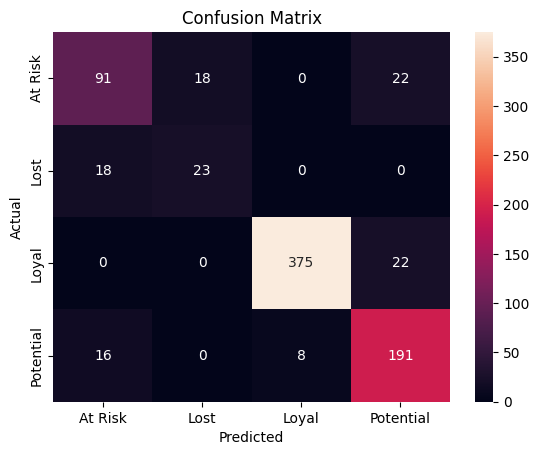

In [19]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [20]:
import pandas as pd

# eg new cust
new_customers = pd.DataFrame({
    'Recency': [15, 200, 60],
    'Frequency': [8, 2, 4],
    'Monetary': [1200, 150, 600]
})


In [21]:
predicted_segments = clf.predict(new_customers)
predicted_labels = le.inverse_transform(predicted_segments)

new_customers['Predicted_Segment'] = predicted_labels
print(new_customers)


   Recency  Frequency  Monetary Predicted_Segment
0       15          8      1200             Loyal
1      200          2       150           At Risk
2       60          4       600             Loyal
